In [99]:
import numpy as np
import os
import warnings

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score, KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [100]:
warnings.filterwarnings("ignore")

if not os.path.exists("plots"):
    os.makedirs("plots")
if not os.path.exists("artifacts"):
    os.makedirs("artifacts")

Load the data

In [101]:
df = pd.read_csv("all_matches.csv")

print("shape:", df.shape)
print(df.head())

shape: (51491, 8)
         date home_team away_team  home_score  away_score tournament  \
0  1872-11-30  Scotland   England           0           0   Friendly   
1  1873-03-08   England  Scotland           4           2   Friendly   
2  1874-03-07  Scotland   England           2           1   Friendly   
3  1875-03-06   England  Scotland           2           2   Friendly   
4  1876-03-04  Scotland   England           3           0   Friendly   

    country  neutral  
0  Scotland    False  
1   England    False  
2  Scotland    False  
3   England    False  
4  Scotland    False  


In [102]:
print("Columns:\n", df.columns.tolist())

Columns:
 ['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'country', 'neutral']


# Basic Cleaning

Converting date column to datetime

In [103]:
df["date"] = pd.to_datetime(df["date"])

Only keeping matches from 1990 onwards - older data is less relevant for modern football

In [104]:
df = df[df["date"] >= "1990-01-01"].reset_index(drop=True)

In [105]:
print(f"Matches after 1990: {len(df)}")

Matches after 1990: 32389


Adding the "outcome" column - this is our target from the home team's perspective

In [106]:
def get_outcome(row):
    if row["home_score"] > row["away_score"]:
        return "Home Win"
    elif row["home_score"] < row["away_score"]:
        return "Away Win"
    else:
        return "Draw"


In [107]:
df["outcome"] = df.apply(get_outcome, axis=1)

In [108]:
print("outcome distribution:")
print(df["outcome"].value_counts())

outcome distribution:
outcome
Home Win    18597
Draw         7737
Away Win     6055
Name: count, dtype: int64


# EDA Plots

Outcome distribution

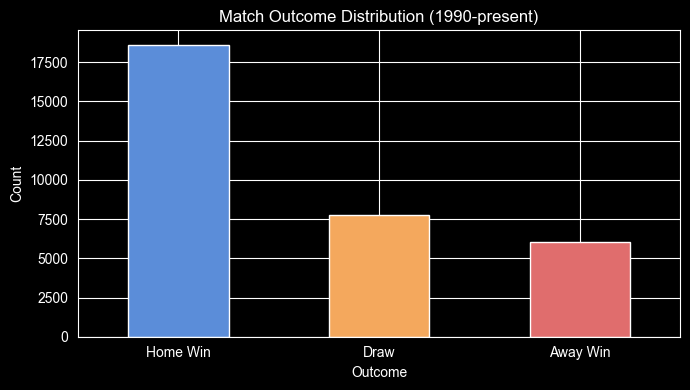

In [109]:
plt.figure(figsize=(7, 4))
colors = ["#5B8DD9", "#F4A85D", "#E06D6D"]
df["outcome"].value_counts().plot(kind="bar", color=colors, edgecolor="white")
plt.title("Match Outcome Distribution (1990-present)")
plt.xlabel("Outcome")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("plots/Match_outcome_distribution_(1990-present).png", dpi=150)
plt.show()

Goal Distribution

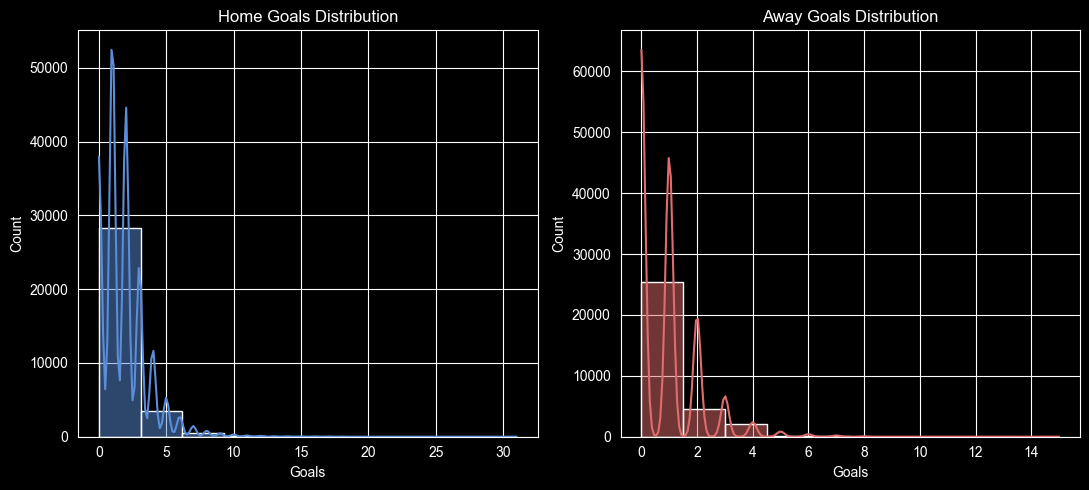

In [110]:
plt.figure(figsize=(11, 5))
plt.subplot(1, 2, 1)
sns.histplot(df["home_score"], bins=10, color="#5B8DD9", kde=True)
plt.title("Home Goals Distribution")
plt.xlabel("Goals")

plt.subplot(1, 2, 2)
sns.histplot(df["away_score"], bins=10, color="#E06D6D", kde=True)
plt.title("Away Goals Distribution")
plt.xlabel("Goals")

plt.tight_layout()
plt.savefig("plots/Home_Goals_Distribution.png", dpi=150)
plt.show()

Tournament Type Breakdown

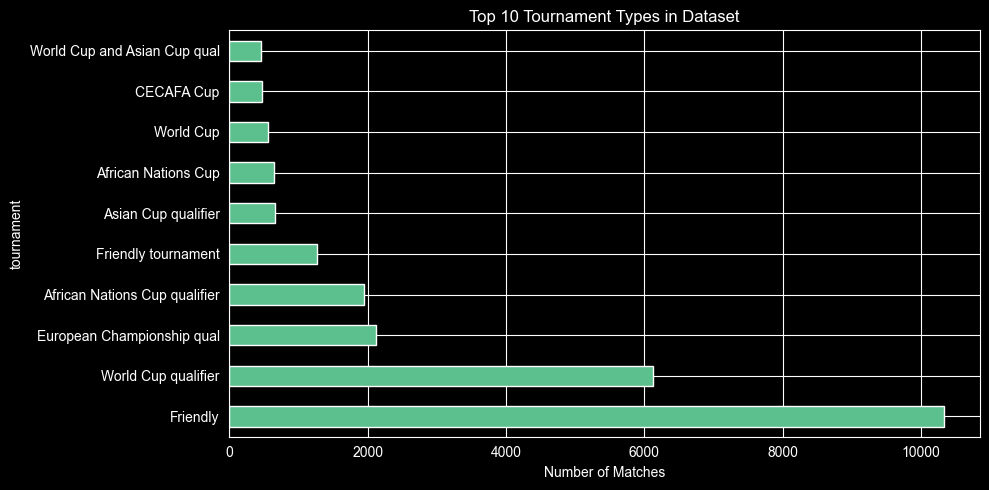

EDA plots saved


In [111]:
plt.figure(figsize=(10, 5))
top_tournaments = df["tournament"].value_counts().head(10)
top_tournaments.plot(kind="barh", color="#5BC08D", edgecolor="white")
plt.title("Top 10 Tournament Types in Dataset")
plt.xlabel("Number of Matches")
plt.tight_layout()
plt.savefig("plots/Tournament_types.png", dpi=150)
plt.show()

print("EDA plots saved")


# Feature Engineering

Sorting by date so we can compute rolling stats correctly

In [112]:
df = df.sort_values("date").reset_index(drop=True)

Function to compute a team's recent form (last N matches)
which returns win rate, goals scored per game, goals conceded per game

In [113]:
def compute_team_stats(team_name, before_date, all_matches, n=10):
    team_matches = all_matches[
        ((all_matches["home_team"] == team_name) | (all_matches["away_team"] == team_name)) &
        (all_matches["date"] < before_date)].tail(n)

    if len(team_matches) == 0:
        return 0.5, 1.0, 1.0  # default values if no history

    wins = 0
    goals_scored = 0
    goals_conceded = 0

    for _, row in team_matches.iterrows():
        if row["home_team"] == team_name:
            goals_scored += row["home_score"]
            goals_conceded += row["away_score"]
            if row["home_score"] > row["away_score"]:
                wins += 1
        else:
            goals_scored += row["away_score"]
            goals_conceded += row["home_score"]
            if row["away_score"] > row["home_score"]:
                wins += 1

    n_matches = len(team_matches)
    return wins / n_matches, goals_scored / n_matches, goals_conceded / n_matches

Function to compute head to head record between two teams

In [114]:
def compute_h2h(home_team, away_team, before_date, all_matches, n=10):
    h2h = all_matches[
        (
            ((all_matches["home_team"] == home_team) & (all_matches["away_team"] == away_team)) |
            ((all_matches["home_team"] == away_team) & (all_matches["away_team"] == home_team))
        ) &
        (all_matches["date"] < before_date)
    ].tail(n)

    if len(h2h) == 0:
        return 0.5  # no history, assume equal

    home_wins = 0
    for _, row in h2h.iterrows():
        if row["home_team"] == home_team and row["home_score"] > row["away_score"]:
            home_wins += 1
        elif row["away_team"] == home_team and row["away_score"] > row["home_score"]:
            home_wins += 1

    return home_wins / len(h2h)

Tournament importance encoding world cup and continental tournaments matter more than friendlies

In [115]:
def encode_tournament(tournament):
    if "FIFA World Cup" in tournament:
        return 3
    elif any(t in tournament for t in ["UEFA Euro", "Copa America", "Africa Cup", "Asian Cup"]):
        return 2
    elif "qualification" in tournament.lower() or "qualifier" in tournament.lower():
        return 1
    else:
        return 0  # friendlies and others


print("\nbuilding features... this takes a few minutes")


building features... this takes a few minutes


Build features for each match using a sample for speed - using matches from 2010 onwards for training this still gives us 10,000+ matches which is plenty

In [116]:
df_train = df[df["date"] >= "2010-01-01"].reset_index(drop=True)

In [117]:
print(f"matches used for feature building: {len(df_train)}")

matches used for feature building: 15826


In [118]:
rows = []
for idx, row in df_train.iterrows():
    if idx % 1000 == 0:
        print(f"  processing match {idx}/{len(df_train)}...")

    home_wr, home_gf, home_ga = compute_team_stats(row["home_team"], row["date"], df)
    away_wr, away_gf, away_ga = compute_team_stats(row["away_team"], row["date"], df)
    h2h_rate = compute_h2h(row["home_team"], row["away_team"], row["date"], df)
    tournament_imp = encode_tournament(row["tournament"])
    is_neutral = 1 if row["neutral"] else 0

    rows.append({
        "home_win_rate":        home_wr,
        "away_win_rate":        away_wr,
        "home_goals_per_game":  home_gf,
        "away_goals_per_game":  away_gf,
        "home_conceded_per_game": home_ga,
        "away_conceded_per_game": away_ga,
        "h2h_home_win_rate":    h2h_rate,
        "form_diff":            home_wr - away_wr,  # simple diff feature
        "goals_diff":           home_gf - away_gf,
        "tournament_importance": tournament_imp,
        "is_neutral":           is_neutral,
        "outcome":              row["outcome"],
        "home_team":            row["home_team"],
        "away_team":            row["away_team"],
        "date":                 row["date"]
    })

  processing match 0/15826...
  processing match 1000/15826...
  processing match 2000/15826...
  processing match 3000/15826...
  processing match 4000/15826...
  processing match 5000/15826...
  processing match 6000/15826...
  processing match 7000/15826...
  processing match 8000/15826...
  processing match 9000/15826...
  processing match 10000/15826...
  processing match 11000/15826...
  processing match 12000/15826...
  processing match 13000/15826...
  processing match 14000/15826...
  processing match 15000/15826...


In [119]:
features_df = pd.DataFrame(rows)
print(f"Feature dataset shape: {features_df.shape}")

Feature dataset shape: (15826, 15)


In [120]:
print(features_df.head())

   home_win_rate  away_win_rate  home_goals_per_game  away_goals_per_game  \
0            0.3            0.4                  1.2                  1.4   
1            0.5            0.4                  1.2                  1.3   
2            0.3            0.4                  0.9                  1.5   
3            0.2            0.5                  1.2                  1.6   
4            0.5            0.5                  1.7                  0.6   

   home_conceded_per_game  away_conceded_per_game  h2h_home_win_rate  \
0                     1.4                     0.8           0.800000   
1                     0.7                     1.2           0.500000   
2                     2.1                     1.3           1.000000   
3                     1.4                     0.9           0.500000   
4                     1.1                     0.7           0.333333   

   form_diff  goals_diff  tournament_importance  is_neutral   outcome  \
0       -0.1        -0.2       

# Prepare for modelling

In [121]:
feature_cols = [
    "home_win_rate", "away_win_rate",
    "home_goals_per_game", "away_goals_per_game",
    "home_conceded_per_game", "away_conceded_per_game",
    "h2h_home_win_rate", "form_diff", "goals_diff",
    "tournament_importance", "is_neutral"
]

In [122]:
X = features_df[feature_cols].values
y = features_df["outcome"].values

Encode labels

In [123]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print("Classes:", le.classes_)

Classes: ['Away Win' 'Draw' 'Home Win']


# Model comparison

In [124]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Comparing models with 5-fold CV...")

Comparing models with 5-fold CV...


Logistic Regression

In [125]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr_scores = cross_val_score(lr, X_scaled, y_encoded, cv=kf, scoring="accuracy")

In [126]:
print(f"Logistic Regression: accuracy = {round(lr_scores.mean(), 4)} +/- {round(lr_scores.std(), 4)}")

Logistic Regression: accuracy = 0.6232 +/- 0.0072


Random Forest (Doesn't need scaling)

In [127]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf_scores = cross_val_score(rf, X, y_encoded, cv=kf, scoring="accuracy")

In [128]:
print(f"Random Forest: \nAccuracy = {round(rf_scores.mean(), 4)} +/- {round(rf_scores.std(), 4)}")

Random Forest: 
Accuracy = 0.6008 +/- 0.0053


Plot Comparison

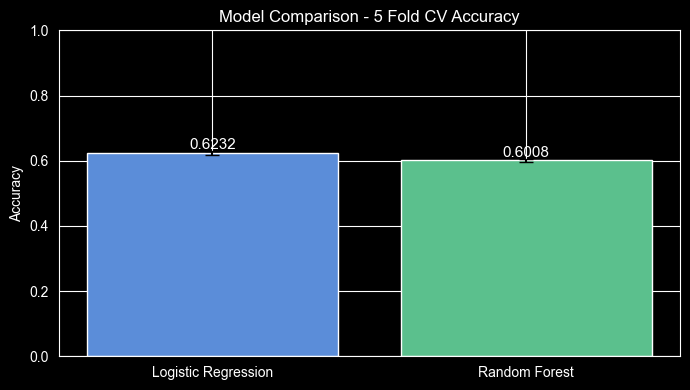

In [129]:
plt.figure(figsize=(7, 4))
model_names = ["Logistic Regression", "Random Forest"]
accuracies = [lr_scores.mean(), rf_scores.mean()]
stds = [lr_scores.std(), rf_scores.std()]
bars = plt.bar(model_names, accuracies, yerr=stds, capsize=5,
               color=["#5B8DD9", "#5BC08D"], edgecolor="white")

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, acc + 0.002,
             str(round(acc, 4)), ha="center", va="bottom", fontsize=11)

plt.title("Model Comparison - 5 Fold CV Accuracy")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("plots/Model_comparison.png", dpi=150)
plt.show()

Picking the best model

In [130]:
if rf_scores.mean() >= lr_scores.mean():
    best_model_name = "Random Forest"
    print("Best model: Random Forest")
else:
    best_model_name = "Logistic Regression"
    print("Best model: Logistic Regression")

Best model: Logistic Regression


# Tune Random Forest

In [131]:
print("Tuning Random Forest with GridSearchCV...")

Tuning Random Forest with GridSearchCV...


In [132]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5],
}

rf_base = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(rf_base, param_grid, cv=kf,
                           scoring="accuracy", n_jobs=-1, verbose=1)
grid_search.fit(X, y_encoded)

Fitting 5 folds for each of 18 candidates, totalling 90 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'min_samples_split': [2, 5], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and paramete

In [133]:
print(f"Best params: {grid_search.best_params_}")
print(f"Best CV accuracy: {round(grid_search.best_score_, 4)}")

tuned_rf = grid_search.best_estimator_

Best params: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Best CV accuracy: 0.6205


# Evaluation on full data

In [134]:
tuned_rf.fit(X, y_encoded)
y_pred = tuned_rf.predict(X)

In [135]:
print("Classification report:")
print(classification_report(y_encoded, y_pred, target_names=le.classes_))

Classification report:
              precision    recall  f1-score   support

    Away Win       0.63      0.54      0.58      2990
        Draw       0.98      0.11      0.19      3742
    Home Win       0.68      0.95      0.79      9094

    accuracy                           0.68     15826
   macro avg       0.76      0.53      0.52     15826
weighted avg       0.74      0.68      0.61     15826



Confusion Matrix

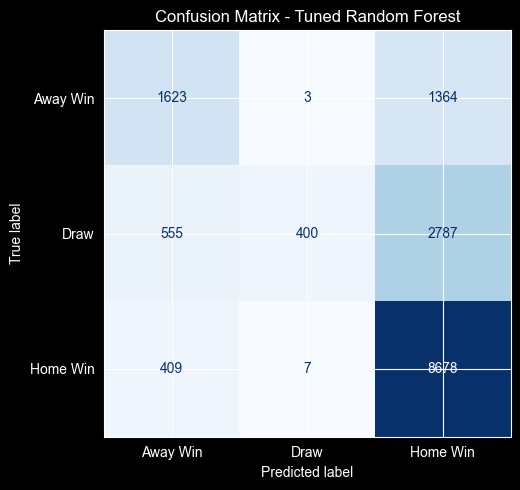

In [136]:
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_encoded, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix - Tuned Random Forest")
plt.tight_layout()
plt.savefig("plots/Confusion_matrix.png", dpi=150)
plt.show()

Feature Importance

In [137]:
importances = pd.Series(tuned_rf.feature_importances_, index=feature_cols).sort_values()

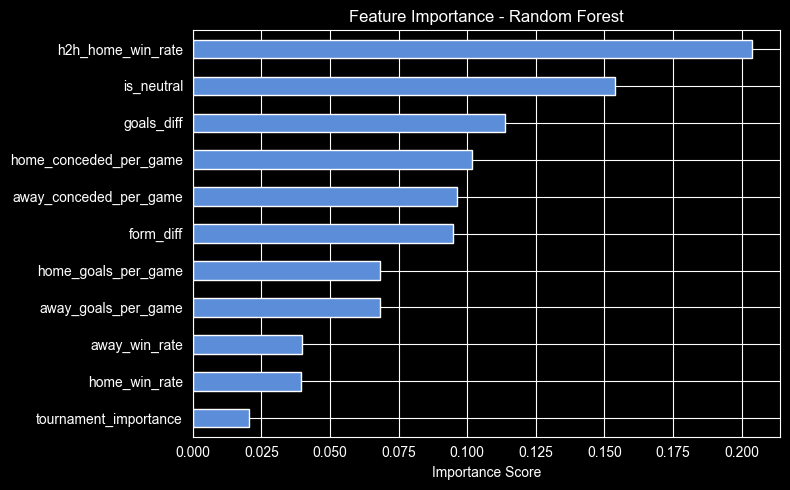

In [138]:
plt.figure(figsize=(8, 5))
importances.plot(kind="barh", color="#5B8DD9")
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig("plots/Feature_importance.png", dpi=150)
plt.show()

In [139]:
print("Top 3 most important features:")
print(importances.sort_values(ascending=False).head(3))

Top 3 most important features:
h2h_home_win_rate    0.203778
is_neutral           0.153789
goals_diff           0.113763
dtype: float64


# Save everything for the streamlit app

Getting all unique teams in the dataset for the app dropdown

In [140]:
all_teams = sorted(list(set(df["home_team"].unique().tolist() + df["away_team"].unique().tolist())))

joblib.dump(tuned_rf, "artifacts/model.pkl")
joblib.dump(scaler, "artifacts/scaler.pkl")
joblib.dump(le, "artifacts/label_encoder.pkl")
joblib.dump(feature_cols, "artifacts/feature_cols.pkl")
joblib.dump(all_teams, "artifacts/all_teams.pkl")
features_df.to_csv("artifacts/features_df.csv", index=False)

Also saving the full historical results for H2H lookup in the app

In [141]:
df.to_csv("artifacts/results_clean.csv", index=False)

print("Artifacts saved:")
print("  artifacts/model.pkl")
print("  artifacts/scaler.pkl")
print("  artifacts/label_encoder.pkl")
print("  artifacts/feature_cols.pkl")
print("  artifacts/all_teams.pkl")
print("  artifacts/features_df.csv")
print("  artifacts/results_clean.csv")

Artifacts saved:
  artifacts/model.pkl
  artifacts/scaler.pkl
  artifacts/label_encoder.pkl
  artifacts/feature_cols.pkl
  artifacts/all_teams.pkl
  artifacts/features_df.csv
  artifacts/results_clean.csv


# Summary

In [142]:
print("Summary:\n")
print(f"Training matches used: {len(features_df)}")
print(f"Best model: {best_model_name}")
print(f"Best CV Accuracy: {round(grid_search.best_score_, 4)}")
print(f"Total teams in dataset: {len(all_teams)}")
print("Plots saved to plots/")


Summary:

Training matches used: 15826
Best model: Logistic Regression
Best CV Accuracy: 0.6205
Total teams in dataset: 252
Plots saved to plots/
